# Exploratory Data Analysis
**Owner: Gr**

Understand both tickers: price paths, trade frequency, intraday spread patterns, and the ZAMAUSDT Apr-14 high-volatility anomaly.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.preprocessing import load_trades, load_all_trades
from src.validation import compute_ob_spread

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

TICKERS = ['WIFUSDT', 'ZAMAUSDT']
DATES   = ['2026-04-12', '2026-04-13', '2026-04-14']

## 1 — Dataset Overview

In [3]:
summary = []
for ticker in TICKERS:
    for date in DATES:
        df = load_trades(ticker, date)
        summary.append({
            'ticker': ticker, 'date': date,
            'n_trades': len(df),
            'price_min': df['price'].min(),
            'price_max': df['price'].max(),
            'price_range_%': (df['price'].max() - df['price'].min()) / df['price'].mean() * 100,
            'total_volume': df['amount'].sum(),
        })

pd.DataFrame(summary).set_index(['ticker', 'date']).round(4)

n_trades  price_min  price_max  price_range_%  \
ticker   date                                                        
WIFUSDT  2026-04-12     10805     0.1870     0.2020         7.8288   
         2026-04-13     14868     0.1850     0.1920         3.7153   
         2026-04-14     29934     0.1900     0.2040         7.1032   
ZAMAUSDT 2026-04-12     31162     0.0244     0.0267         9.0261   
         2026-04-13     32408     0.0248     0.0264         5.9201   
         2026-04-14    578015     0.0255     0.0429        50.8574   

                     total_volume  
ticker   date                      
WIFUSDT  2026-04-12  1.098088e+07  
         2026-04-13  1.743785e+07  
         2026-04-14  3.518266e+07  
ZAMAUSDT 2026-04-12  1.669338e+08  
         2026-04-13  1.436057e+08  
         2026-04-14  1.820294e+09

## 2 — Price Paths

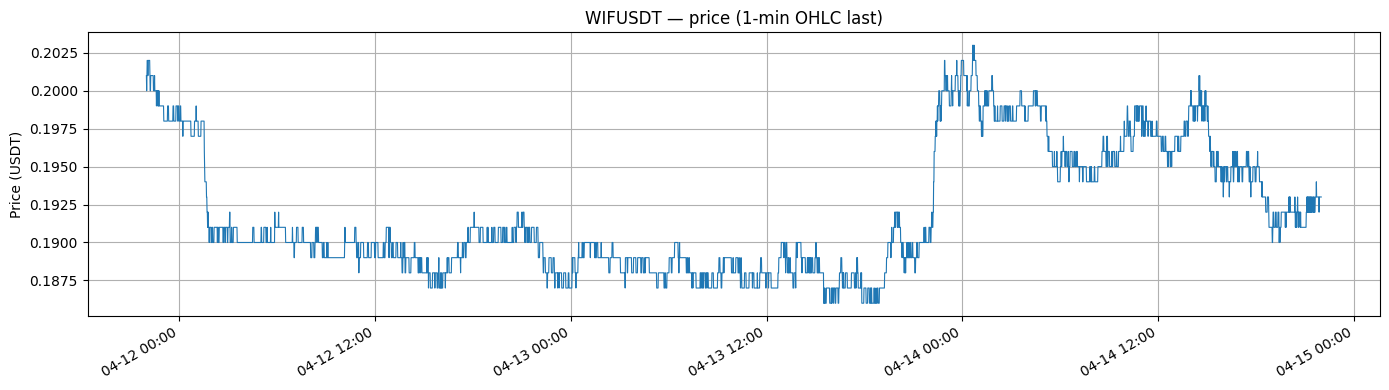

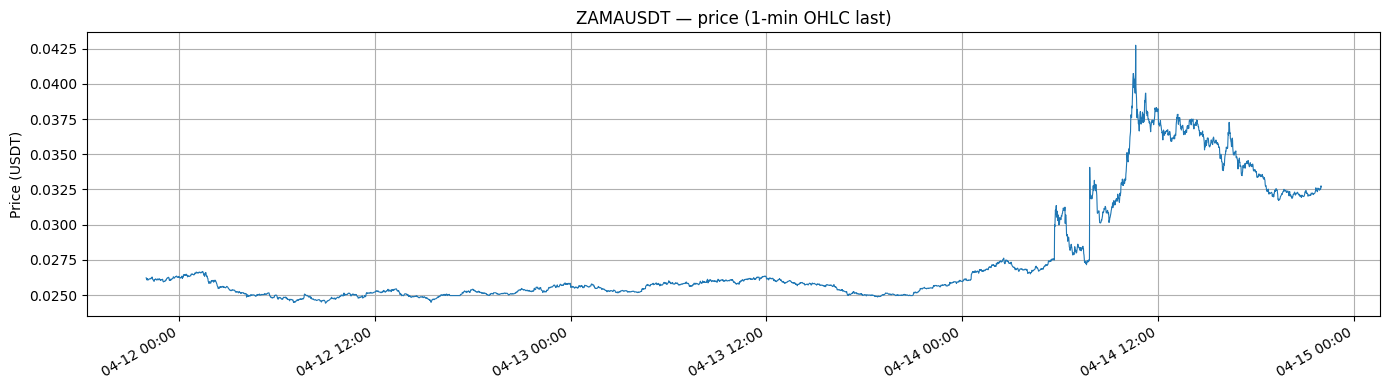

In [4]:
for ticker in TICKERS:
    all_trades = load_all_trades(ticker)
    price_1m = all_trades['price'].resample('1min').last().ffill()

    fig, ax = plt.subplots()
    ax.plot(price_1m.index, price_1m.values, lw=0.8)
    ax.set_title(f'{ticker} — price (1-min OHLC last)')
    ax.set_ylabel('Price (USDT)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## 3 — Trade Frequency Heatmap (trades per hour)

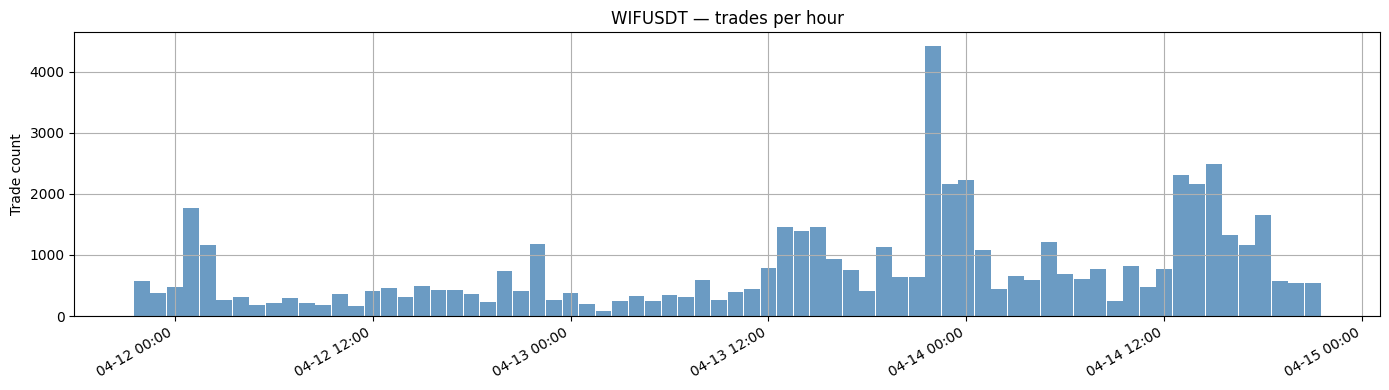

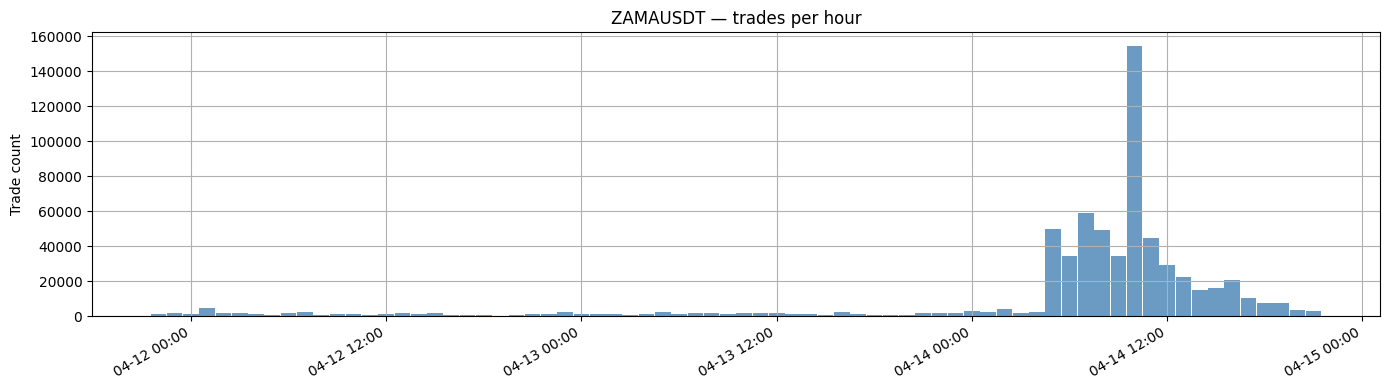

In [5]:
for ticker in TICKERS:
    all_trades = load_all_trades(ticker)
    hourly = all_trades.resample('1h').size()

    fig, ax = plt.subplots()
    ax.bar(hourly.index, hourly.values, width=0.04, color='steelblue', alpha=0.8)
    ax.set_title(f'{ticker} — trades per hour')
    ax.set_ylabel('Trade count')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## 4 — Order-Book Spread: Intraday Pattern

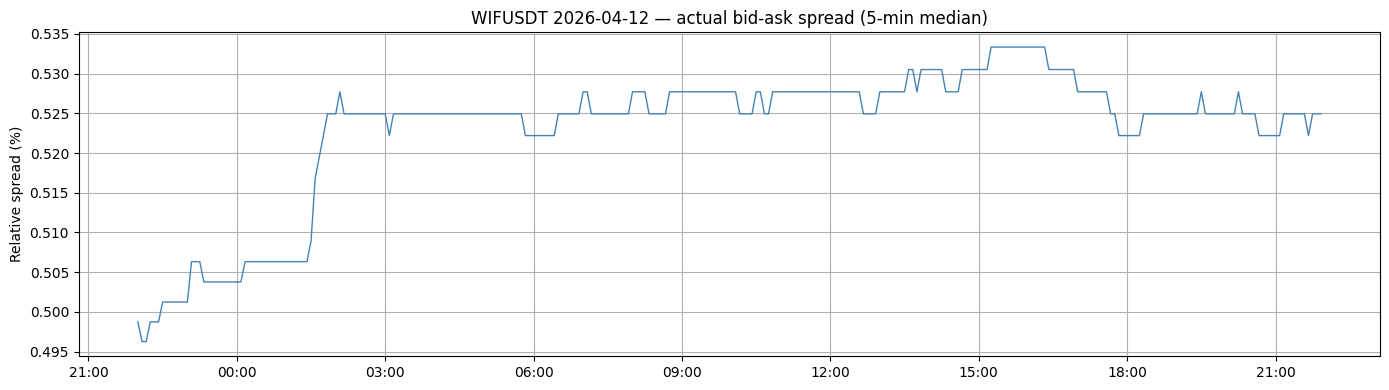

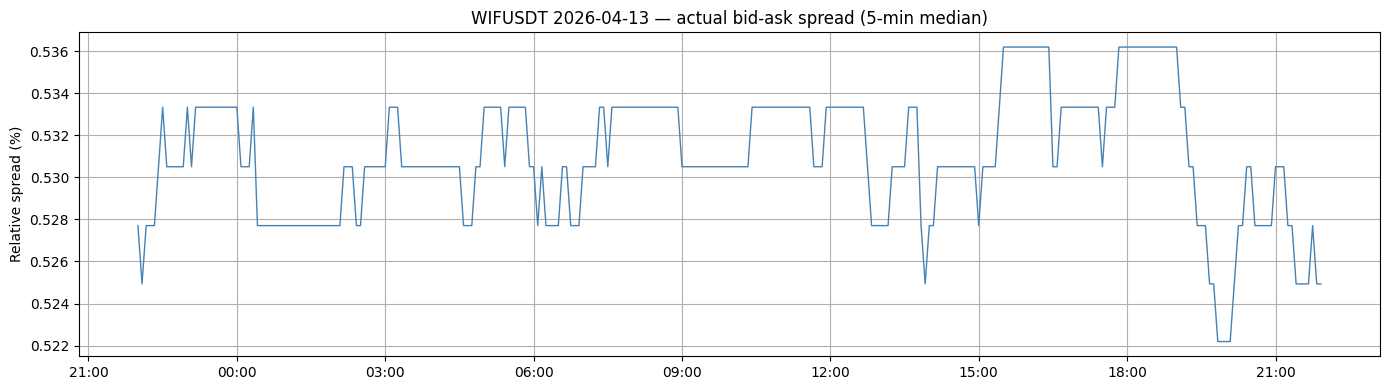

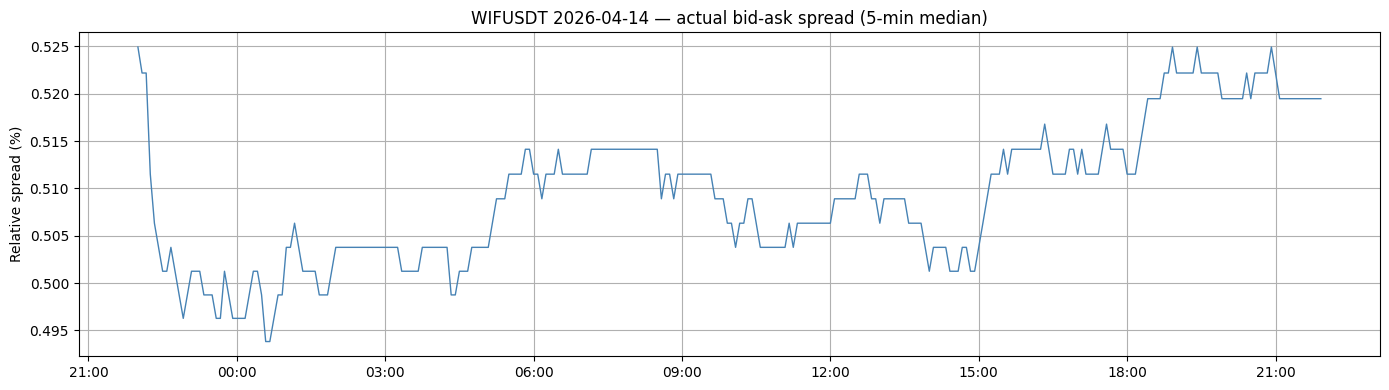

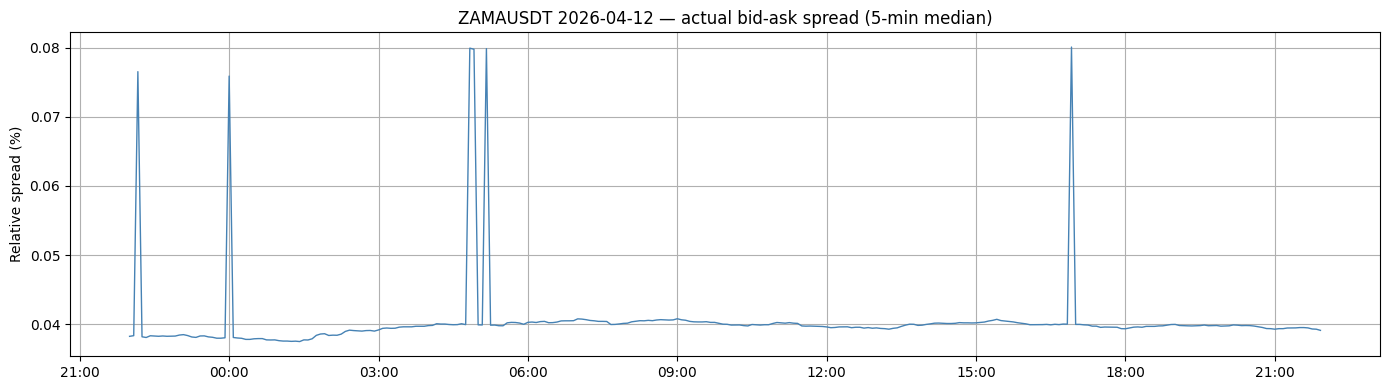

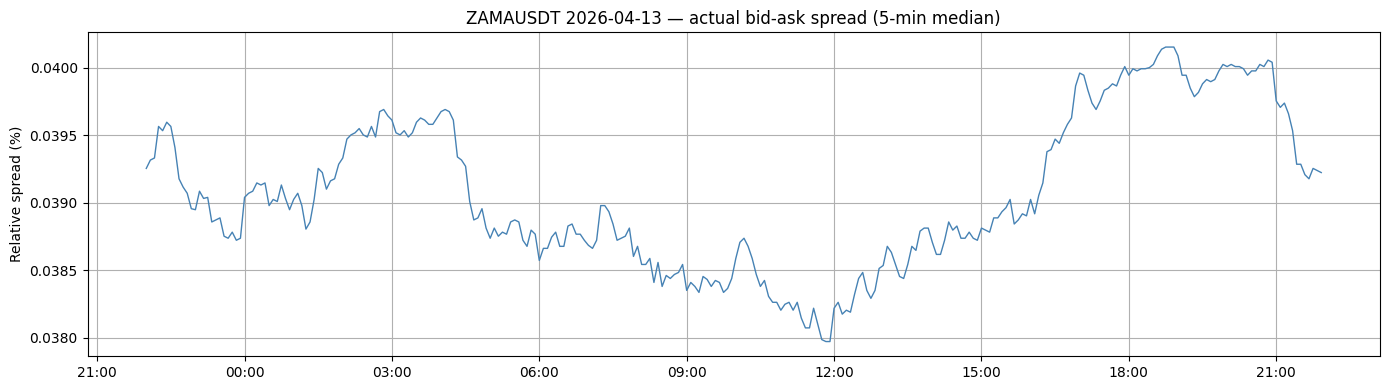

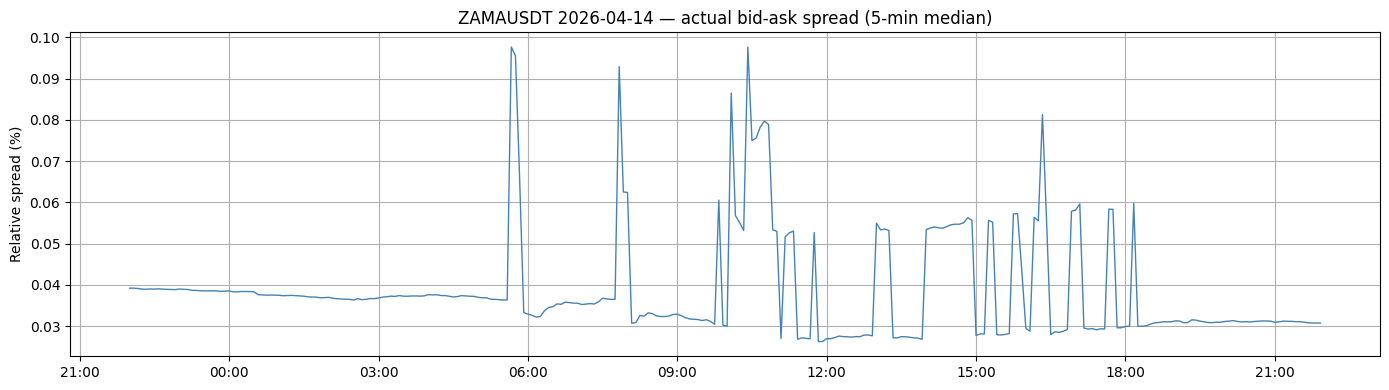

In [6]:
for ticker in TICKERS:
    for date in DATES:
        ob = compute_ob_spread(ticker, date)
        ob_5m = ob.resample('5min').median()

        fig, ax = plt.subplots()
        ax.plot(ob_5m.index, ob_5m.values * 100, lw=1.0, color='steelblue')
        ax.set_title(f'{ticker} {date} — actual bid-ask spread (5-min median)')
        ax.set_ylabel('Relative spread (%)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        fig.tight_layout()
        plt.show()

## 5 — ZAMAUSDT Apr-14 Anomaly Deep-Dive

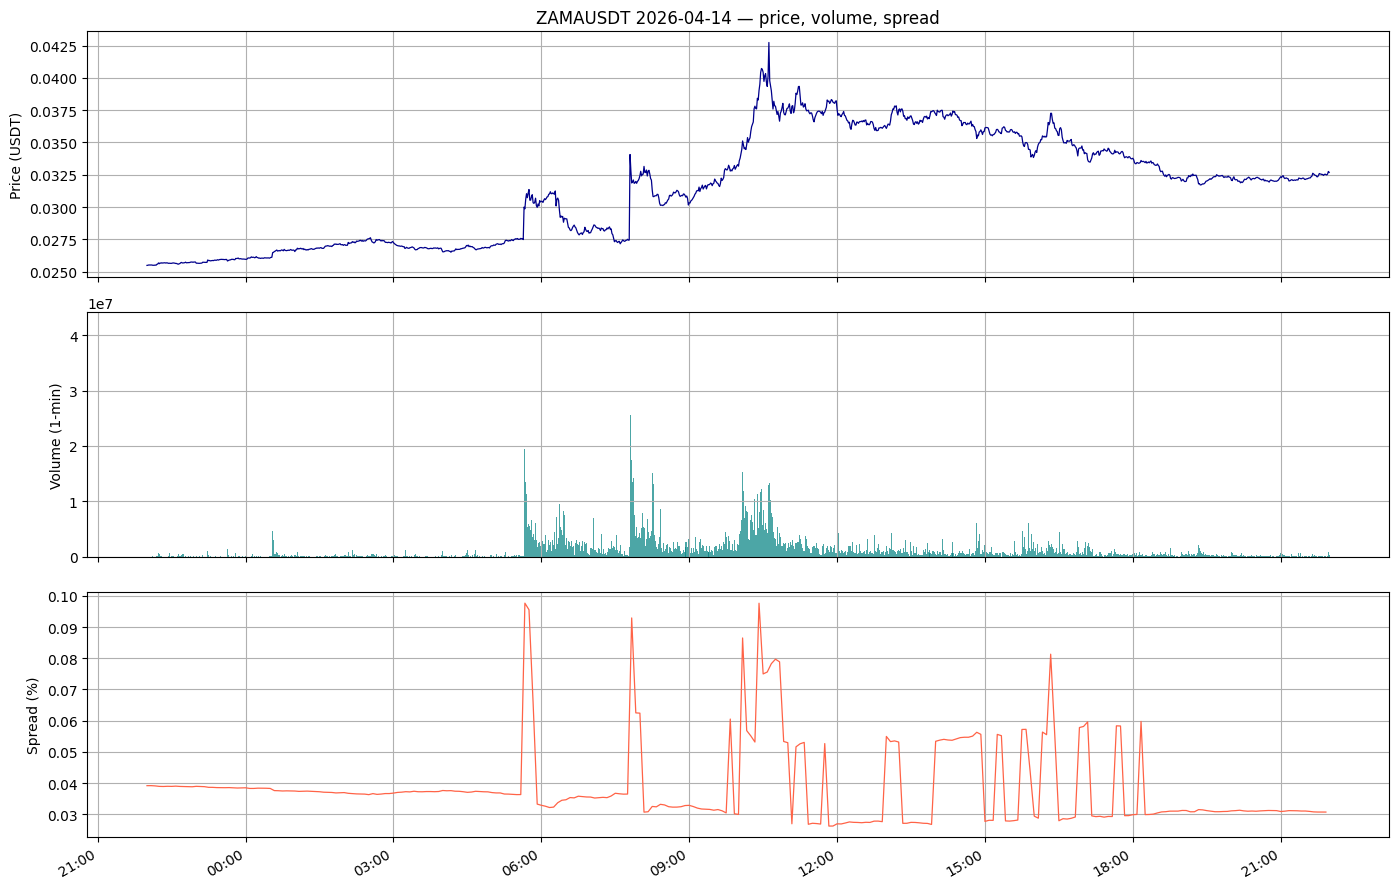

Price return on Apr-14: 28.2 %


In [7]:
ticker, date = 'ZAMAUSDT', '2026-04-14'
trades = load_trades(ticker, date)
ob = compute_ob_spread(ticker, date)

price_1m = trades['price'].resample('1min').last().ffill()
vol_1m   = trades['amount'].resample('1min').sum()
ob_5m    = ob.resample('5min').median() * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(price_1m.index, price_1m.values, lw=0.9, color='darkblue')
axes[0].set_ylabel('Price (USDT)')
axes[0].set_title(f'{ticker} {date} — price, volume, spread')

axes[1].bar(vol_1m.index, vol_1m.values, width=0.0007, color='teal', alpha=0.7)
axes[1].set_ylabel('Volume (1-min)')

axes[2].plot(ob_5m.index, ob_5m.values, lw=0.9, color='tomato')
axes[2].set_ylabel('Spread (%)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print('Price return on Apr-14:', round((trades['price'].iloc[-1] / trades['price'].iloc[0] - 1) * 100, 1), '%')

## 6 — Inter-Trade Time Distribution

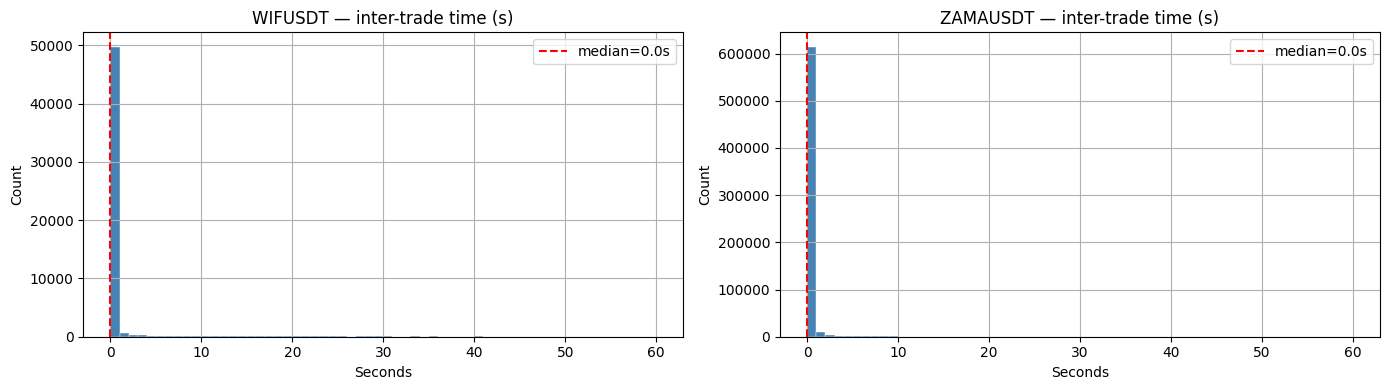

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, ticker in zip(axes, TICKERS):
    trades = load_all_trades(ticker)
    dt_sec = trades.index.to_series().diff().dt.total_seconds().dropna()
    dt_sec = dt_sec[dt_sec < 60]  # clip outliers for readability
    ax.hist(dt_sec, bins=60, color='steelblue', edgecolor='white', lw=0.3)
    ax.set_title(f'{ticker} — inter-trade time (s)')
    ax.set_xlabel('Seconds')
    ax.set_ylabel('Count')
    ax.axvline(dt_sec.median(), color='red', ls='--', label=f'median={dt_sec.median():.1f}s')
    ax.legend()

fig.tight_layout()
plt.show()